In [4]:
import pandas as pd
import glob
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
DATA_DIR = Path("data\processed")   # change if needed

# ============================================================
# LOAD ALL FILES
# ============================================================
files = glob.glob(str(DATA_DIR / "*.csv"))

dfs = {}

for f in files:
    name = Path(f).stem
    df = pd.read_csv(f)

    # Find date column robustly
    date_col = [c for c in df.columns if c.lower() == "date"][0]

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).drop_duplicates(subset=[date_col])
    df = df.set_index(date_col)

    dfs[name] = df
    print(f"Loaded {name}: {df.shape}")


def detect_frequency(df):
    diffs = df.index.to_series().diff().dropna()
    median_diff = diffs.median()

    if median_diff <= pd.Timedelta(days=3):
        return "daily"
    else:
        return "monthly"

daily_dfs = {}
monthly_dfs = {}

for name, df in dfs.items():
    freq = detect_frequency(df)
    print(f"{name}: {freq}")

    if freq == "daily":
        daily_dfs[name] = df
    else:
        monthly_dfs[name] = df


# cap date
cutoff = pd.Timestamp("2025-12-31")

# use SPX/equity daily dates as master
master = pd.DataFrame(index=daily_dfs["equity_market_dynamics_features"].index)
master = master.loc[master.index <= cutoff]

master_daily = master.copy()

for name, df in daily_dfs.items():
    df = df.loc[df.index <= cutoff].copy()
    df = df.add_prefix(f"{name}__")   # avoid duplicate column names
    master_daily = master_daily.join(df, how="left")

print("After merging daily:", master_daily.shape)


master_all = master_daily.copy()

monthly_cols = []

for name, df in monthly_dfs.items():
    df = df.loc[df.index <= cutoff].copy()
    df = df.add_prefix(f"{name}__")
    
    master_all = master_all.join(df, how="left")
    monthly_cols.extend(df.columns.tolist())

master_all[monthly_cols] = master_all[monthly_cols].ffill()

print("After merging monthly:", master_all.shape)
print("Number of monthly columns:", len(monthly_cols))
print("Total columns:", master_all.shape[1])

master_all.to_csv('features_aligned_ffill_macro.csv')

Loaded bond_Features: (6540, 2)
Loaded Commodity_Inflation_Shock_Features: (6540, 3)
Loaded credit_features: (6540, 5)
Loaded CrossAsset_RiskSignals_features: (6540, 2)
Loaded Economic_Activity_Indicators_features: (315, 2)
Loaded equity_market_dynamics_features: (6540, 5)
Loaded Global_RiskEnv_features: (6540, 5)
Loaded Interest_Rate_Environment_features: (6540, 7)
Loaded Macro_Inflation_Environment_features: (315, 6)
Loaded Monetary_Conditions_features: (314, 3)
Loaded Recession_Indicator_Features: (315, 1)
Loaded Safe_Haven_Features: (6540, 5)
Loaded Volatility_Risk_Sentiment_features: (6540, 3)
bond_Features: daily
Commodity_Inflation_Shock_Features: daily
credit_features: daily
CrossAsset_RiskSignals_features: daily
Economic_Activity_Indicators_features: monthly
equity_market_dynamics_features: daily
Global_RiskEnv_features: daily
Interest_Rate_Environment_features: daily
Macro_Inflation_Environment_features: monthly
Monetary_Conditions_features: monthly
Recession_Indicator_Featur

In [5]:
eda_df = master_all.dropna()

print("Original:", master_all.shape)
print("EDA:", eda_df.shape)

eda_df.to_csv('features_model_ready_v1.csv')

Original: (6540, 49)
EDA: (6267, 49)


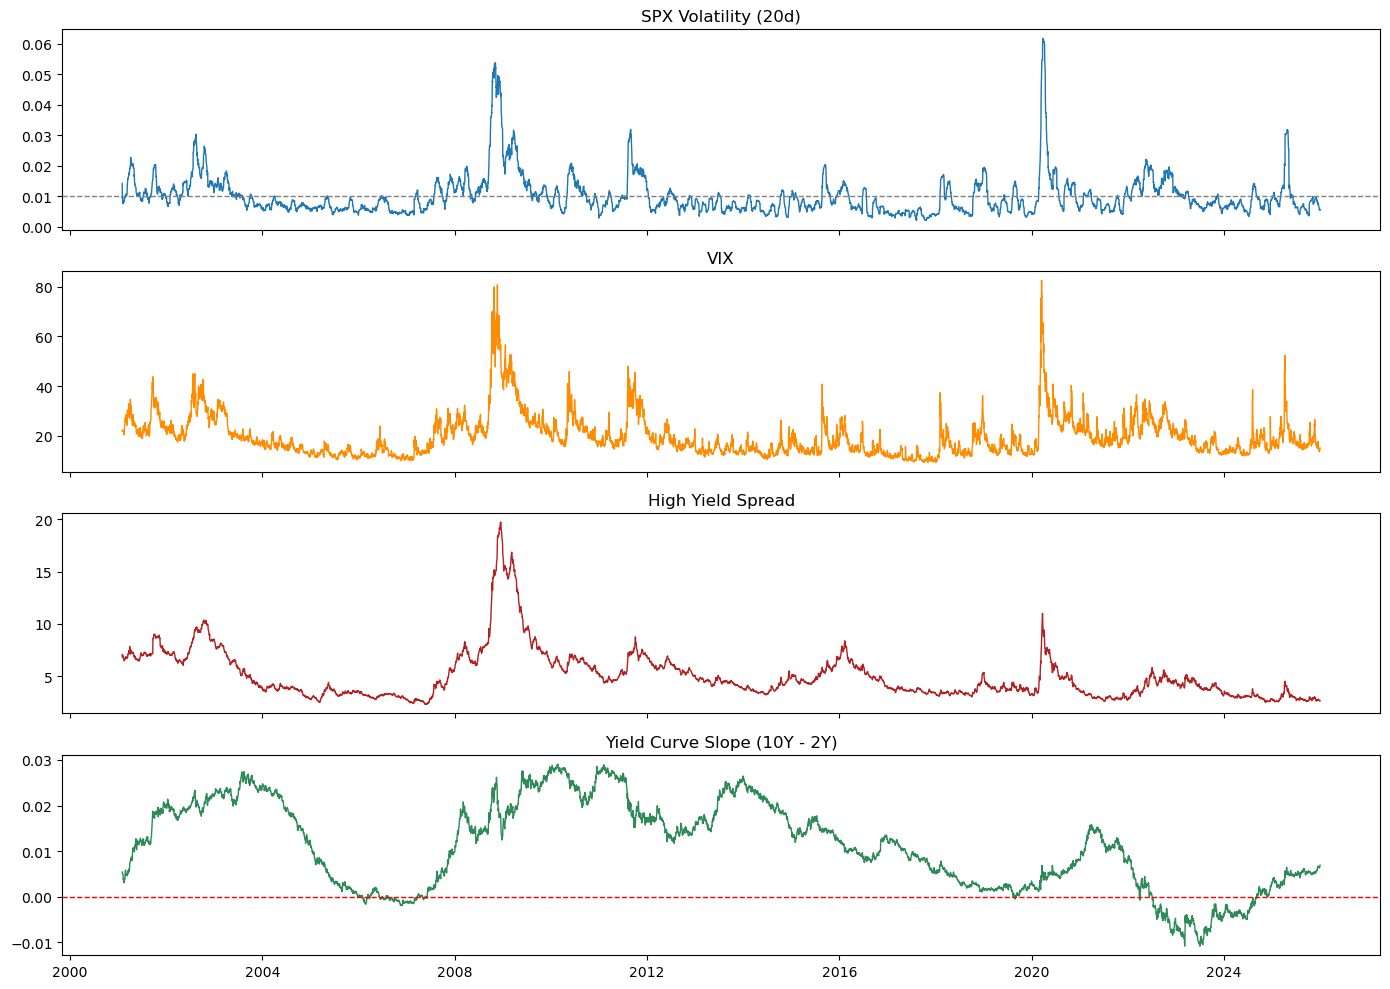

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# SPX Volatility
axes[0].plot(eda_df.index, eda_df['equity_market_dynamics_features__SPX_volatility_20d'], lw=1)
axes[0].set_title("SPX Volatility (20d)")
axes[0].axhline(
    eda_df['equity_market_dynamics_features__SPX_volatility_20d'].mean(),
    linestyle='--',
    color='gray',
    lw=1
)

# VIX
axes[1].plot(eda_df.index, eda_df['Volatility_Risk_Sentiment_features__VIX'], lw=1, color='darkorange')
axes[1].set_title("VIX")

# HY Spread
axes[2].plot(eda_df.index, eda_df['credit_features__HY_Spread'], lw=1, color='firebrick')
axes[2].set_title("High Yield Spread")

# Yield Curve Slope 10y-2y
axes[3].plot(eda_df.index, eda_df['Interest_Rate_Environment_features__Slope_10_2'], lw=1, color='seagreen')
axes[3].set_title("Yield Curve Slope (10Y - 2Y)")
axes[3].axhline(0, linestyle='--', color='red', lw=1)

plt.tight_layout()
plt.show()

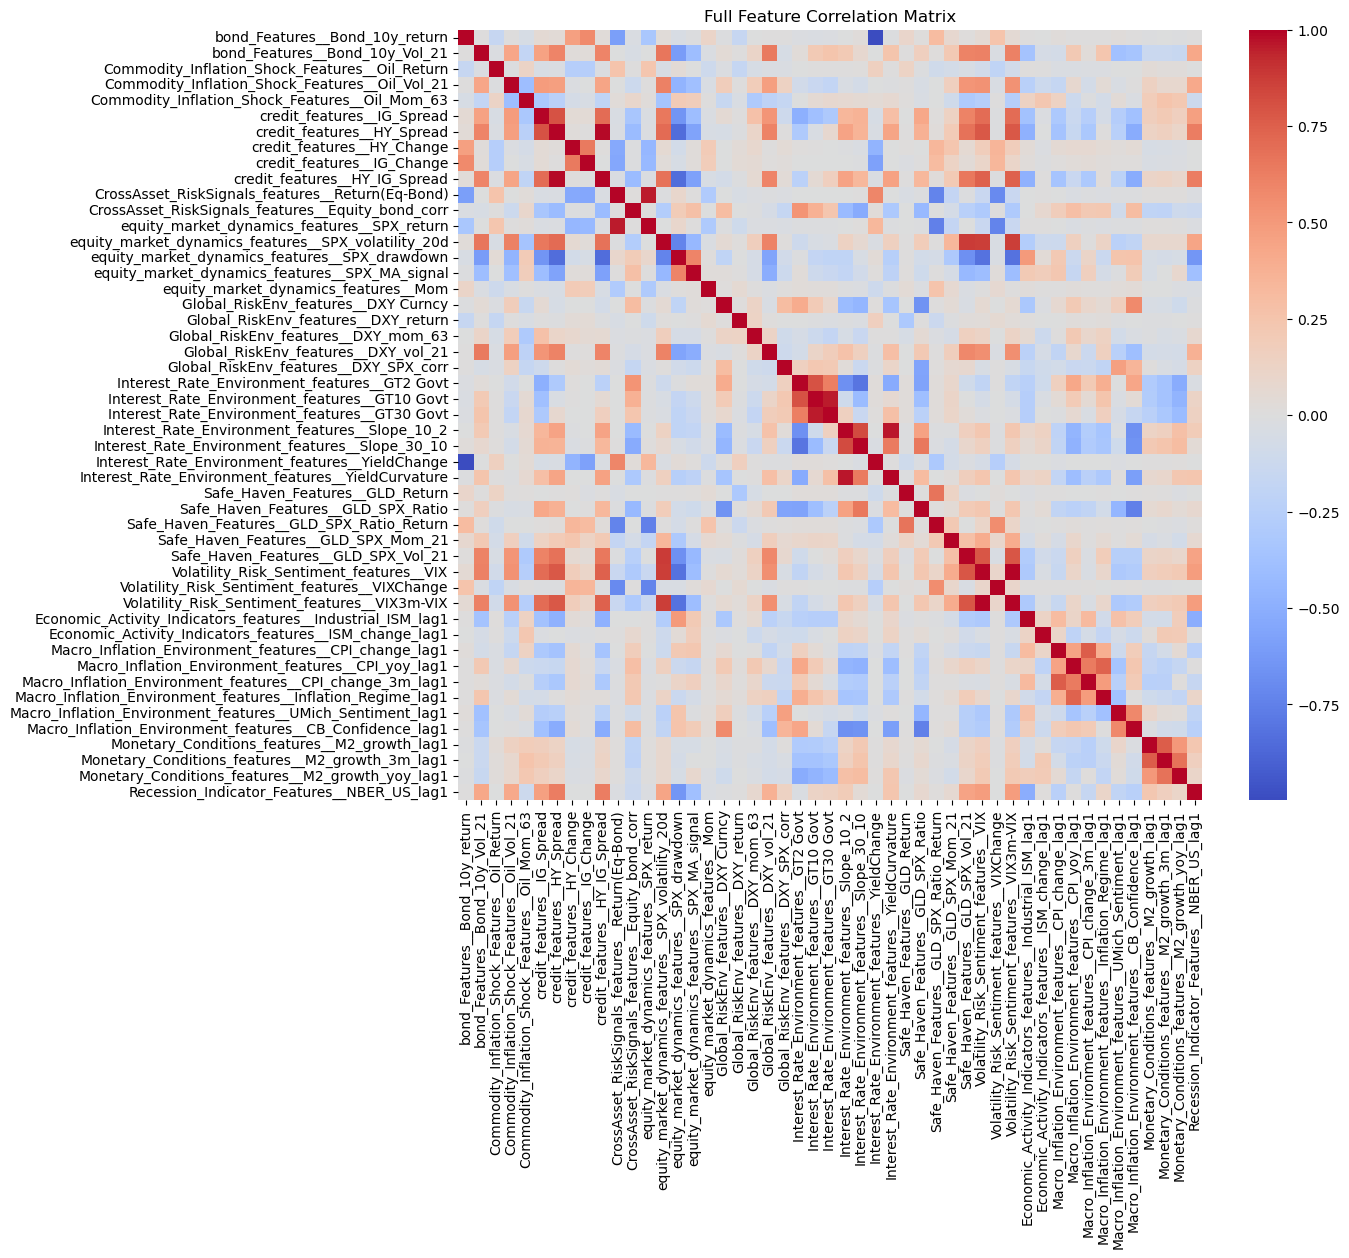

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# correlation matrix
corr = eda_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Full Feature Correlation Matrix")
plt.show()

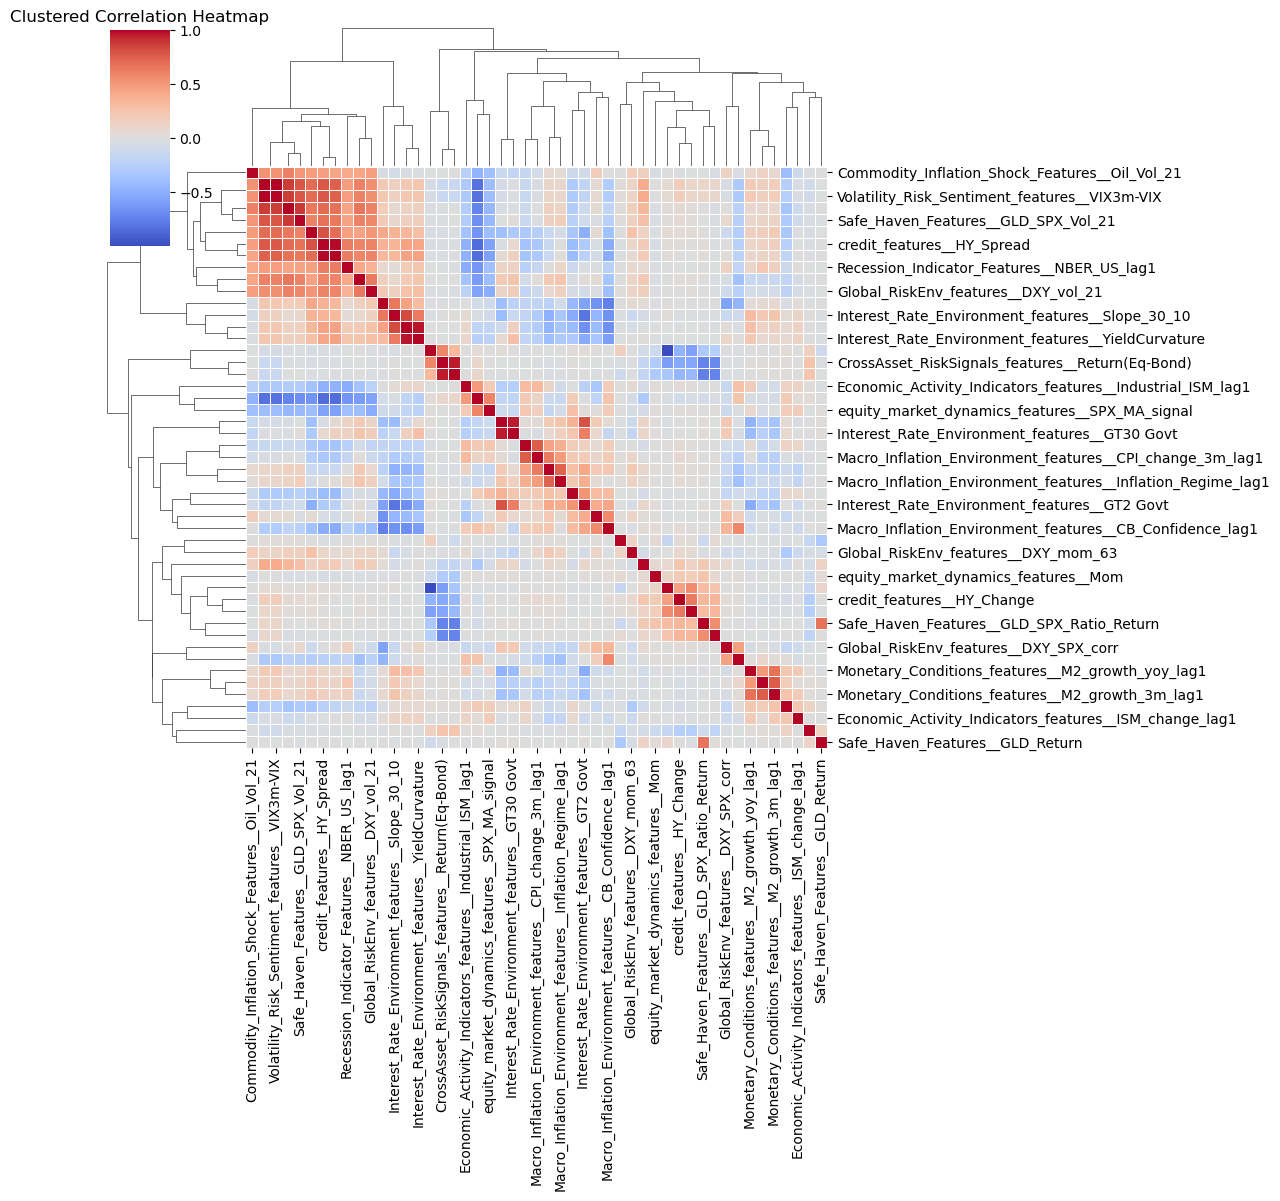

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    eda_df.corr(),
    cmap='coolwarm',
    center=0,
    figsize=(12, 12),
    linewidths=0.5
)

plt.title("Clustered Correlation Heatmap")
plt.show()

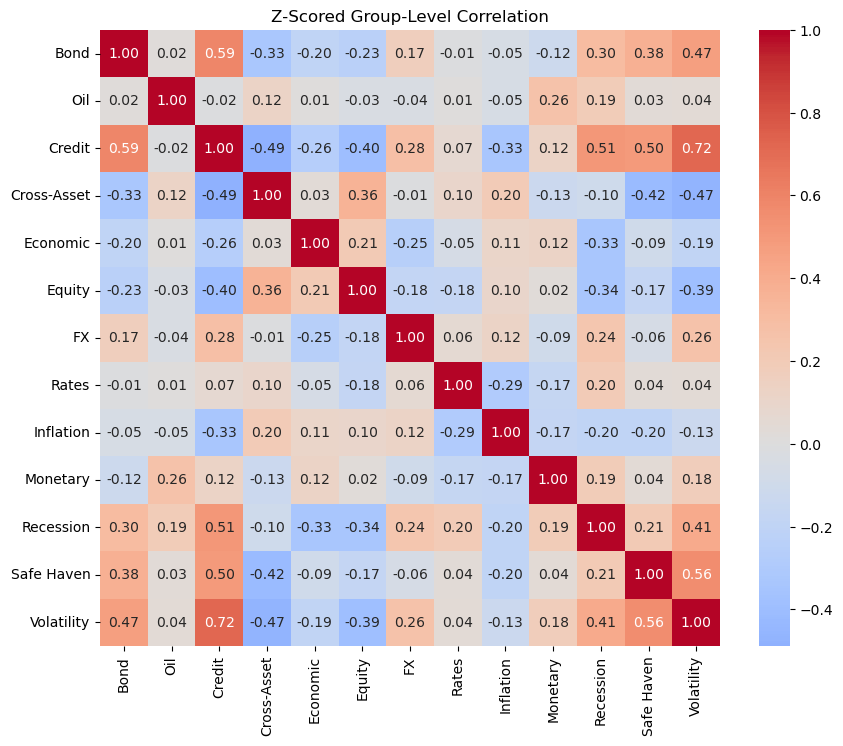

In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Z-score normalization ---
scaler = StandardScaler()
z_df = pd.DataFrame(
    scaler.fit_transform(eda_df),
    index=eda_df.index,
    columns=eda_df.columns
)

# --- Step 2: Define groups (your structure) ---
feature_groups = {
    "Bond": [c for c in z_df.columns if "bond_Features" in c],
    "Oil": [c for c in z_df.columns if "Commodity_Inflation_Shock_Features" in c],
    "Credit": [c for c in z_df.columns if "credit_features" in c],
    "Cross-Asset": [c for c in z_df.columns if "CrossAsset_RiskSignals" in c],
    "Economic": [c for c in z_df.columns if "Economic_Activity" in c],
    "Equity": [c for c in z_df.columns if "equity_market_dynamics" in c],
    "FX": [c for c in z_df.columns if "Global_RiskEnv" in c],
    "Rates": [c for c in z_df.columns if "Interest_Rate_Environment" in c],
    "Inflation": [c for c in z_df.columns if "Macro_Inflation" in c],
    "Monetary": [c for c in z_df.columns if "Monetary_Conditions" in c],
    "Recession": [c for c in z_df.columns if "Recession_Indicator" in c],
    "Safe Haven": [c for c in z_df.columns if "Safe_Haven" in c],
    "Volatility": [c for c in z_df.columns if "Volatility_Risk_Sentiment" in c]
}

# --- Step 3: Aggregate groups ---
group_df = pd.DataFrame(index=z_df.index)

for group, cols in feature_groups.items():
    group_df[group] = z_df[cols].mean(axis=1)

# --- Step 4: Correlation heatmap ---
group_corr = group_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(group_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Z-Scored Group-Level Correlation")
plt.show()

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Use original dataframe (not grouped)
X = eda_df.copy()

# Optional: drop highly discrete variables if needed
X = X.drop(columns=['Macro_Inflation_Environment_features__Inflation_Regime_lag1', 'Recession_Indicator_Features__NBER_US_lag1'])

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort
vif_data = vif_data.sort_values(by="VIF", ascending=False)

display(vif_data)

C:\Users\Mina_\anaconda3\envs\research\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,bond_Features__Bond_10y_return,inf
5,credit_features__IG_Spread,inf
6,credit_features__HY_Spread,inf
9,credit_features__HY_IG_Spread,inf
12,equity_market_dynamics_features__SPX_return,inf
10,CrossAsset_RiskSignals_features__Return(Eq-Bond),inf
34,Volatility_Risk_Sentiment_features__VIX,inf
31,Safe_Haven_Features__GLD_SPX_Ratio_Return,inf
24,Interest_Rate_Environment_features__GT30 Govt,inf
23,Interest_Rate_Environment_features__GT10 Govt,inf


C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\447174598.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_vif, x="VIF", y="Feature", ax=axes[0], palette="Reds_r")
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\447174598.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_vif, x="VIF", y="Feature", ax=axes[1], palette="Greens_r")


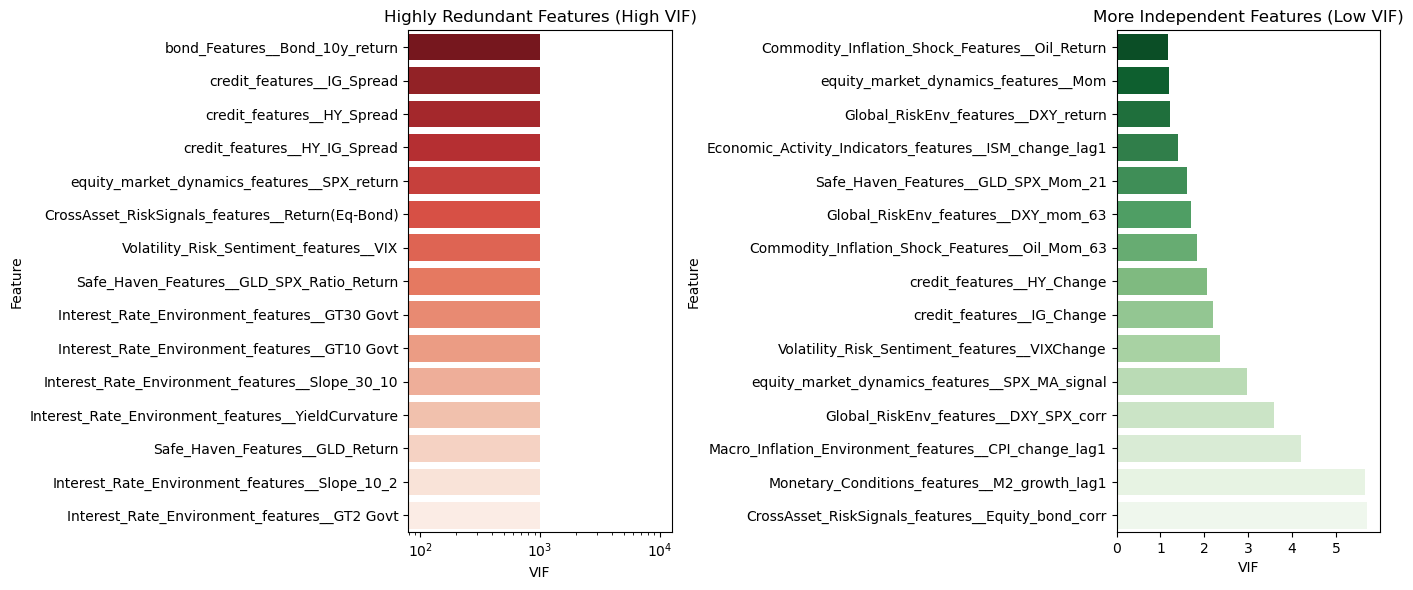

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

vif_plot = vif_data.copy()

# Replace inf for plotting
vif_plot["VIF"] = vif_plot["VIF"].replace(np.inf, 1000)

# Top 15 (highest VIF)
top_vif = vif_plot.sort_values(by="VIF", ascending=False).head(15)

# Bottom 15 (lowest VIF)
bottom_vif = vif_plot.sort_values(by="VIF", ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- Top ---
sns.barplot(data=top_vif, x="VIF", y="Feature", ax=axes[0], palette="Reds_r")
axes[0].set_title("Highly Redundant Features (High VIF)")
axes[0].set_xscale("log")

# --- Bottom ---
sns.barplot(data=bottom_vif, x="VIF", y="Feature", ax=axes[1], palette="Greens_r")
axes[1].set_title("More Independent Features (Low VIF)")

plt.tight_layout()
plt.show()

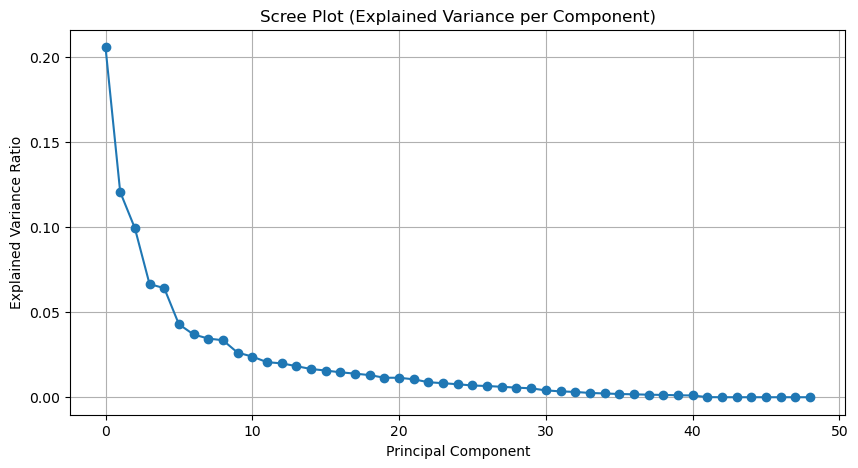

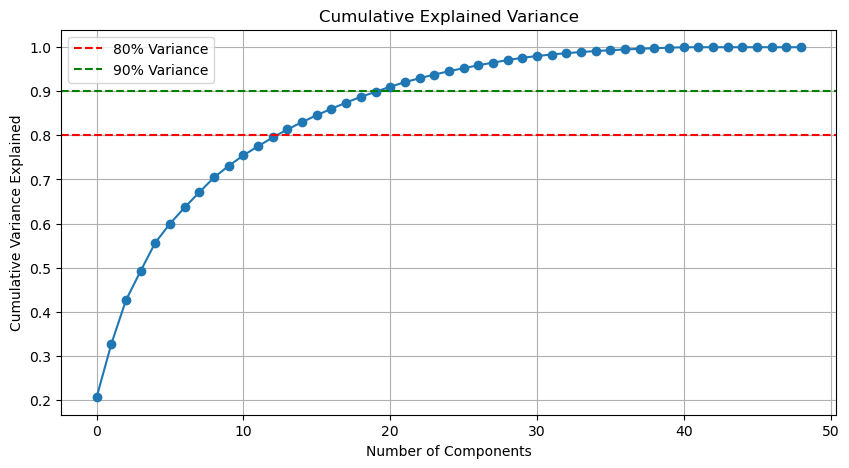

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Standardize ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(eda_df)

# --- Step 2: PCA ---
pca = PCA()
pca.fit(X_scaled)

# --- Explained variance ---
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# --- Scree Plot ---
plt.figure(figsize=(10,5))
plt.plot(explained_var, marker='o')
plt.title("Scree Plot (Explained Variance per Component)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.show()

# --- Cumulative Variance Plot ---
plt.figure(figsize=(10,5))
plt.plot(cumulative_var, marker='o')
plt.axhline(0.8, linestyle='--', color='red', label='80% Variance')
plt.axhline(0.9, linestyle='--', color='green', label='90% Variance')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()
plt.grid()
plt.show()

In [16]:
# cumulative variance already computed before
n_components = 10

variance_30 = cumulative_var[n_components - 1]

print(f"Cumulative variance explained by first {n_components} components: {variance_30:.4f}")

Cumulative variance explained by first 10 components: 0.7308


In [17]:
for i in [5, 10, 20, 30]:
    print(f"{i} PCs explain {cumulative_var[i-1]:.2%} of variance")

5 PCs explain 55.67% of variance
10 PCs explain 73.08% of variance
20 PCs explain 89.88% of variance
30 PCs explain 97.60% of variance


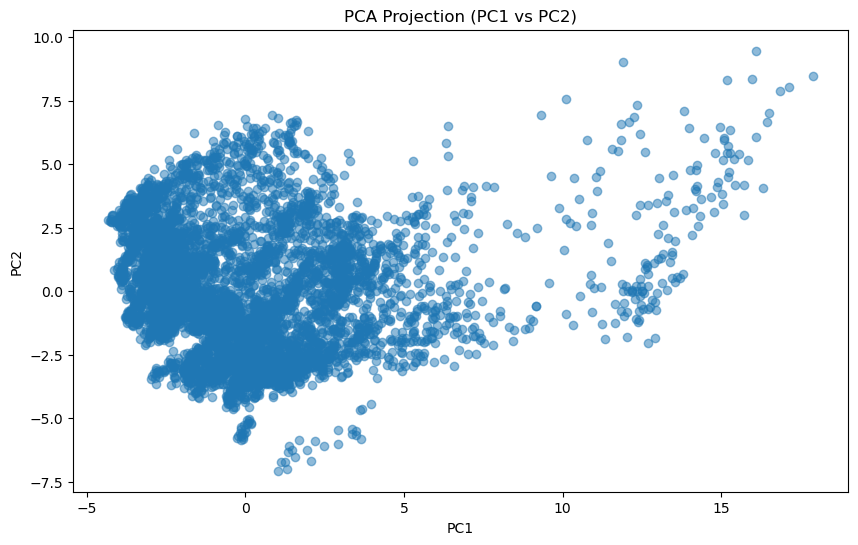

In [18]:
# PCA with 10 components
pca = PCA(n_components=10)
components = pca.fit_transform(X_scaled)

# Scatter plot (first 2 PCs)
plt.figure(figsize=(10,6))
plt.scatter(components[:,0], components[:,1], alpha=0.5)
plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

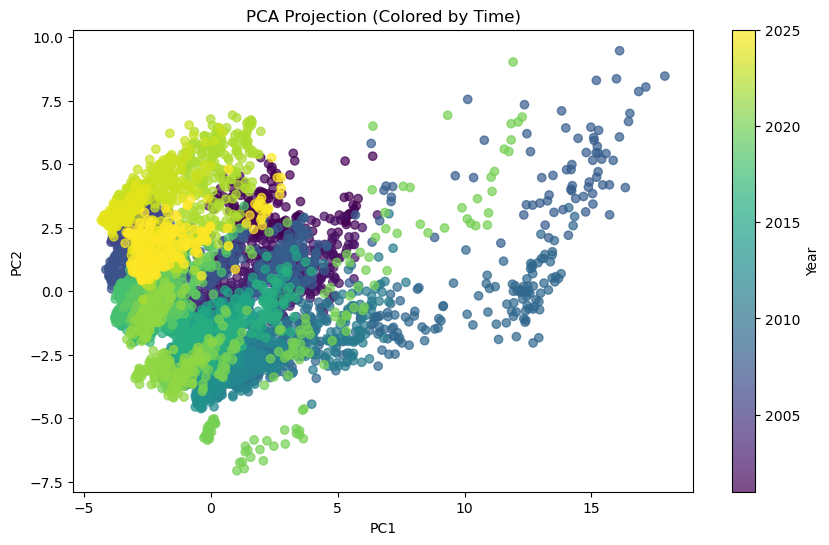

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(components[:,0], components[:,1],
            c=eda_df.index.year, cmap='viridis', alpha=.7)
plt.colorbar(label='Year')
plt.title("PCA Projection (Colored by Time)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [20]:
from sklearn.cluster import KMeans

# Use the PCA components you already created
X_pca = components  # (from PCA with 10 components)

# Try 3 regimes (very common choice)
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Add labels back to dataframe
eda_df['Regime_KMeans'] = labels

C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\2552737436.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['Regime_KMeans'] = labels


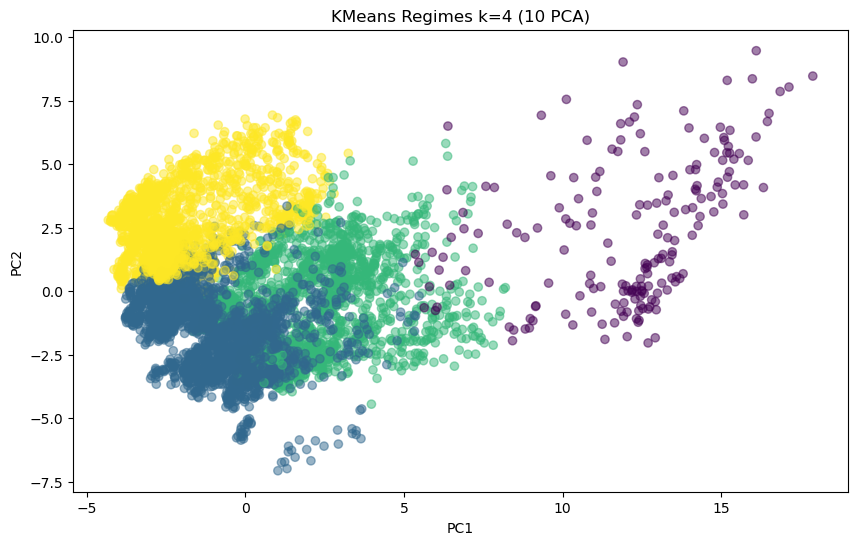

In [21]:
pca = PCA(n_components=20)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(components[:,0], components[:,1],
            c=labels, cmap='viridis', alpha=0.5)

plt.title("KMeans Regimes k=4 (10 PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\2054984819.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\2054984819.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['Regime_Smoothed'] = (
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\2054984819.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

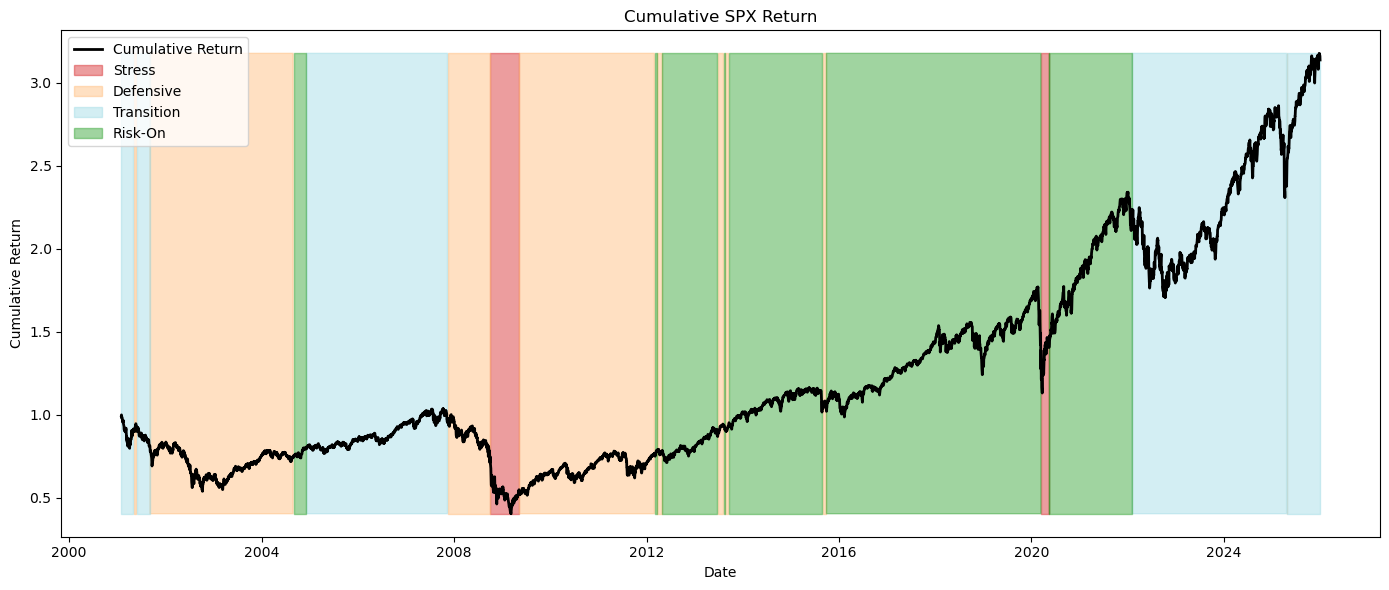

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Build cumulative return
eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()

# 2. Smooth raw KMeans labels
eda_df['Regime_Smoothed'] = (
    eda_df['Regime_KMeans']
    .rolling(10, min_periods=1)
    .apply(lambda x: x.mode()[0], raw=False)
)

# 3. Rank regimes by average SPX return
regime_rank = (
    eda_df.groupby('Regime_Smoothed')['equity_market_dynamics_features__SPX_return']
    .mean()
    .sort_values()
)

# Example: lowest return regime = 0, highest return regime = 3
regime_map = {old_label: new_label for new_label, old_label in enumerate(regime_rank.index)}
eda_df['Regime_Ordered'] = eda_df['Regime_Smoothed'].map(regime_map)

# 4. Assign meaningful colors after ordering
# 0 = worst/stress, 3 = best/risk-on
regime_colors = {
    0: '#d62728',  # red
    1: '#ffbb78',  # orange
    2: '#9edae5',  # light blue
    3: '#2ca02c'   # green
}

regime_names = {
    0: 'Stress',
    1: 'Defensive',
    2: 'Transition',
    3: 'Risk-On'
}


# 5. Plot
plt.figure(figsize=(14, 6))

ymin = eda_df['SPX_cum_return'].min()
ymax = eda_df['SPX_cum_return'].max()

# cumulative return line
plt.plot(
    eda_df.index,
    eda_df['SPX_cum_return'],
    color='black',
    linewidth=2,
    label='Cumulative Return'
)

# shaded backgrounds
for r in sorted(eda_df['Regime_Ordered'].dropna().unique()):
    mask = eda_df['Regime_Ordered'] == r
    plt.fill_between(
        eda_df.index,
        ymin,
        ymax,
        where=mask,
        color=regime_colors[r],
        alpha=0.45,
        label=regime_names[r]
    )

plt.title("Cumulative SPX Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
regime_summary = eda_df.groupby('Regime_Smoothed')[[
    'equity_market_dynamics_features__SPX_return',
    'equity_market_dynamics_features__SPX_volatility_20d',
    'Volatility_Risk_Sentiment_features__VIX',
    'credit_features__HY_Spread',
    'bond_Features__Bond_10y_return'
]].mean()

regime_summary.round(4)

,equity_market_dynamics_features__SPX_return,equity_market_dynamics_features__SPX_volatility_20d,Volatility_Risk_Sentiment_features__VIX,credit_features__HY_Spread,bond_Features__Bond_10y_return
Regime_Smoothed,,,,,
0.0,-0.0006,0.0348,48.9123,13.8815,0.0002
1.0,0.0005,0.0078,16.4987,4.2837,-0.0000
2.0,0.0001,0.0119,23.2080,6.4883,0.0001
3.0,0.0002,0.0090,17.4413,3.7074,-0.0001


C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\555581110.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\555581110.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['Regime_Smoothed'] = (
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\555581110.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

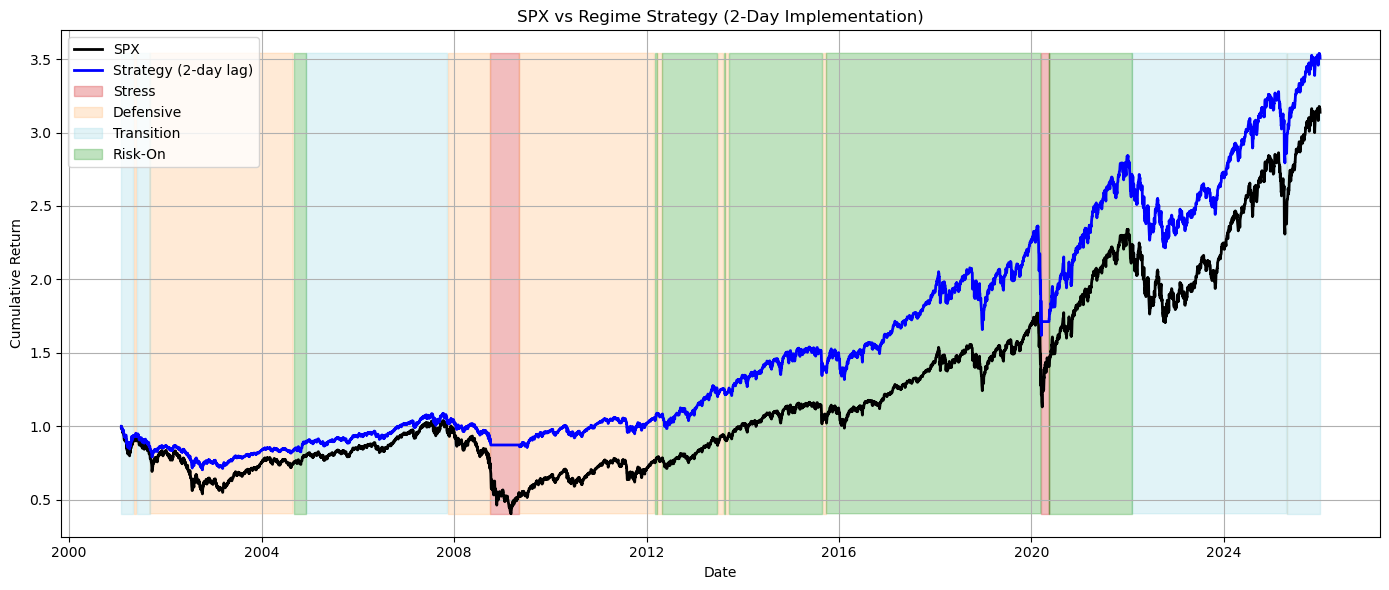

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Build cumulative SPX return
eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()

# 2. Smooth raw KMeans labels
eda_df['Regime_Smoothed'] = (
    eda_df['Regime_KMeans']
    .rolling(10, min_periods=1)
    .apply(lambda x: x.mode()[0], raw=False)
)

# 3. Rank regimes by average SPX return
regime_rank = (
    eda_df.groupby('Regime_Smoothed')['equity_market_dynamics_features__SPX_return']
    .mean()
    .sort_values()
)

# 4. Re-label regimes (worst → best)
regime_map = {old_label: new_label for new_label, old_label in enumerate(regime_rank.index)}
eda_df['Regime_Ordered'] = eda_df['Regime_Smoothed'].map(regime_map)

# 5. Colors and names
regime_colors = {
    0: '#d62728',
    1: '#ffbb78',
    2: '#9edae5',
    3: '#2ca02c'
}

regime_names = {
    0: 'Stress',
    1: 'Defensive',
    2: 'Transition',
    3: 'Risk-On'
}

# 6. Position mapping
position_map = {
    0: 0.0,
    1: 0.5,
    2: 0.75,
    3: 1.0
}

eda_df['Position_raw'] = eda_df['Regime_Ordered'].map(position_map)

# ✅ 7. SECOND-DAY IMPLEMENTATION (FIXED)
eda_df['Position'] = eda_df['Position_raw'].shift(2)

# 8. Strategy returns
eda_df['Strategy_Return'] = (
    eda_df['Position'] * eda_df['equity_market_dynamics_features__SPX_return']
)

# 9. Fill NaNs
eda_df['Position'] = eda_df['Position'].fillna(0)
eda_df['Strategy_Return'] = eda_df['Strategy_Return'].fillna(0)

# 10. Strategy cumulative
eda_df['Strategy_Cum'] = (1 + eda_df['Strategy_Return']).cumprod()

# =========================
# FINAL PLOT (CLEAN)
# =========================
plt.figure(figsize=(14, 6))

ymin = np.min([
    eda_df['SPX_cum_return'].min(),
    eda_df['Strategy_Cum'].min()
])

ymax = np.max([
    eda_df['SPX_cum_return'].max(),
    eda_df['Strategy_Cum'].max()
])

# SPX
plt.plot(
    eda_df.index,
    eda_df['SPX_cum_return'],
    color='black',
    linewidth=2,
    label='SPX'
)

# Strategy
plt.plot(
    eda_df.index,
    eda_df['Strategy_Cum'],
    color='blue',
    linewidth=2,
    label='Strategy (2-day lag)'
)

# Regime shading
for r in sorted(eda_df['Regime_Ordered'].dropna().unique()):
    mask = eda_df['Regime_Ordered'] == r
    plt.fill_between(
        eda_df.index,
        ymin,
        ymax,
        where=mask,
        color=regime_colors[r],
        alpha=0.3,
        label=regime_names[r]
    )

# Fix duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.title("SPX vs Regime Strategy (2-Day Implementation)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\1543122046.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\1543122046.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['Regime_Smoothed'] = (
C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\1543122046.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

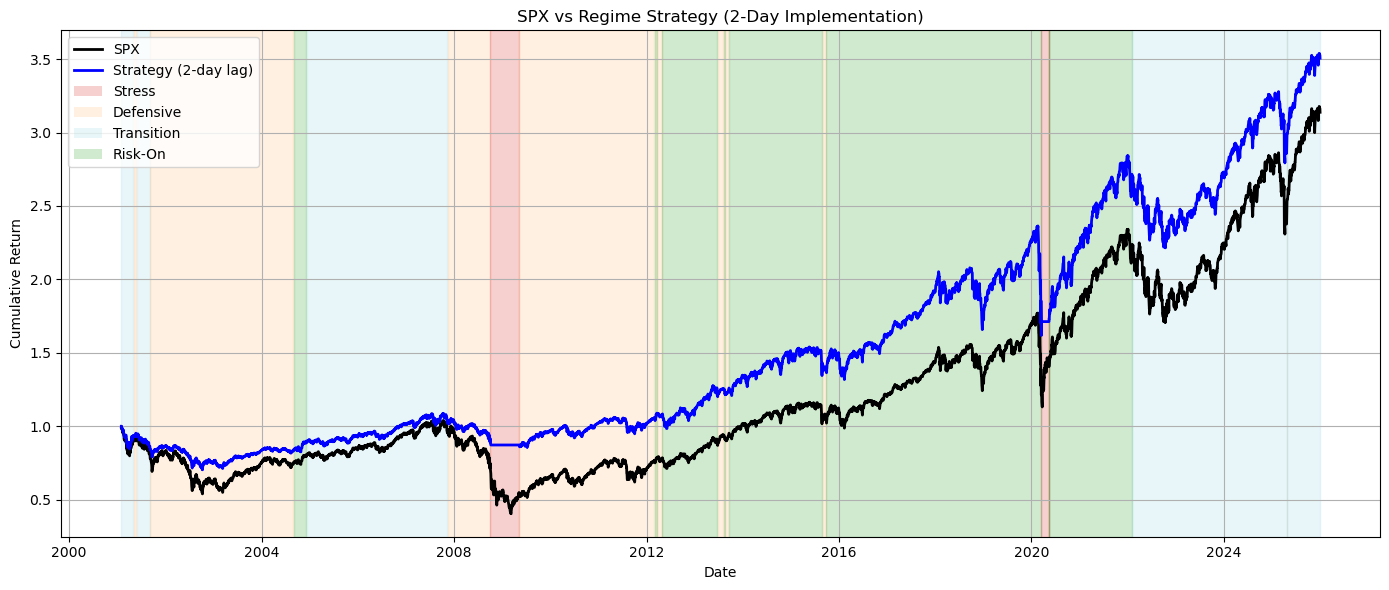

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Build cumulative SPX return
eda_df['SPX_cum_return'] = (1 + eda_df['equity_market_dynamics_features__SPX_return']).cumprod()

# 2. Smooth raw KMeans labels
eda_df['Regime_Smoothed'] = (
    eda_df['Regime_KMeans']
    .rolling(10, min_periods=1)
    .apply(lambda x: x.mode()[0], raw=False)
)

# 3. Rank regimes by average SPX return
regime_rank = (
    eda_df.groupby('Regime_Smoothed')['equity_market_dynamics_features__SPX_return']
    .mean()
    .sort_values()
)

# 4. Re-label regimes (worst -> best)
regime_map = {old_label: new_label for new_label, old_label in enumerate(regime_rank.index)}
eda_df['Regime_Ordered'] = eda_df['Regime_Smoothed'].map(regime_map)

# 5. Colors and names
regime_colors = {
    0: '#d62728',  # Stress
    1: '#ffbb78',  # Defensive
    2: '#9edae5',  # Transition
    3: '#2ca02c'   # Risk-On
}

regime_names = {
    0: 'Stress',
    1: 'Defensive',
    2: 'Transition',
    3: 'Risk-On'
}

# 6. Position mapping
position_map = {
    0: 0.0,
    1: 0.5,
    2: 0.75,
    3: 1.0
}

eda_df['Position_raw'] = eda_df['Regime_Ordered'].map(position_map)

# 7. SECOND-DAY implementation
eda_df['Position'] = eda_df['Position_raw'].shift(2)

# 8. Strategy returns
eda_df['Strategy_Return'] = (
    eda_df['Position'] * eda_df['equity_market_dynamics_features__SPX_return']
)

# 9. Fill NaNs
eda_df['Position'] = eda_df['Position'].fillna(0)
eda_df['Strategy_Return'] = eda_df['Strategy_Return'].fillna(0)

# 10. Strategy cumulative return
eda_df['Strategy_Cum'] = (1 + eda_df['Strategy_Return']).cumprod()

# 11. y-limits
ymin = eda_df[['SPX_cum_return', 'Strategy_Cum']].min().min()
ymax = eda_df[['SPX_cum_return', 'Strategy_Cum']].max().max()

# =========================
# PLOT
# =========================
plt.figure(figsize=(14, 6))

# Shade continuous regime blocks
regime_change = eda_df['Regime_Ordered'].ne(eda_df['Regime_Ordered'].shift()).cumsum()

for _, block in eda_df.groupby(regime_change):
    regime = block['Regime_Ordered'].iloc[0]
    if pd.notna(regime):
        plt.axvspan(
            block.index[0],
            block.index[-1],
            color=regime_colors[regime],
            alpha=0.22
        )

# SPX line
plt.plot(
    eda_df.index,
    eda_df['SPX_cum_return'],
    color='black',
    linewidth=2,
    label='SPX'
)

# Strategy line
plt.plot(
    eda_df.index,
    eda_df['Strategy_Cum'],
    color='blue',
    linewidth=2,
    label='Strategy (2-day lag)'
)

# Custom legend for regimes
from matplotlib.patches import Patch
regime_patches = [
    Patch(facecolor=regime_colors[r], alpha=0.22, label=regime_names[r])
    for r in sorted(regime_names.keys())
]

line_handles, line_labels = plt.gca().get_legend_handles_labels()
plt.legend(
    line_handles + regime_patches,
    line_labels + [regime_names[r] for r in sorted(regime_names.keys())],
    loc='upper left'
)

plt.title("SPX vs Regime Strategy (2-Day Implementation)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
def performance_stats(returns, name="Strategy"):
    ann_ret = (1 + returns).prod()**(252/len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    
    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    
    print(f"--- {name} ---")
    print(f"Return: {ann_ret:.2%}")
    print(f"Vol: {ann_vol:.2%}")
    print(f"Sharpe: {sharpe:.2f}")
    print(f"Max DD: {max_dd:.2%}")
    print()

# Compare
performance_stats(eda_df['equity_market_dynamics_features__SPX_return'], "SPX")
performance_stats(eda_df['Strategy_Return'], "Regime Strategy")

--- SPX ---
Return: 4.71%
Vol: 19.25%
Sharpe: 0.24
Max DD: -61.03%

--- Regime Strategy ---
Return: 5.17%
Vol: 12.90%
Sharpe: 0.40
Max DD: -31.54%



In [27]:
eda_df['Turnover'] = eda_df['Position'].diff().abs()

print("Avg Turnover:", eda_df['Turnover'].mean())

Avg Turnover: 0.002034790935205873


C:\Users\Mina_\AppData\Local\Temp\ipykernel_31056\2911678831.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df['Turnover'] = eda_df['Position'].diff().abs()


In [28]:
regime_stats = eda_df.groupby('Regime_Ordered').agg({
    'equity_market_dynamics_features__SPX_return': ['mean', 'std', 'count'],
    'Strategy_Return': ['mean']
})

regime_stats

equity_market_dynamics_features__SPX_return                  \
                                                      mean       std count   
Regime_Ordered                                                               
0                                                -0.000636  0.034020   191   
1                                                 0.000120  0.012988  1790   
2                                                 0.000188  0.010063  1853   
3                                                 0.000478  0.009331  2433   

               Strategy_Return  
                          mean  
Regime_Ordered                  
0                    -0.000502  
1                     0.000061  
2                     0.000138  
3                     0.000491